In [2]:
from scipy.io import loadmat

# SpikeInterface
from probeinterface import Probe
import spikeinterface as si

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

"""
    This script preprocesses the Intan data.
    Input:
        .rhs files from Intan
    Output:
        Checkpoint after preprocessing
        Checkpoint after thresholding and calculating MUA peak locations and firing rate
"""

OUT_BASE = OUT_BASE.parent / 'results' # TODO Temporary

# Local reference params, both floats
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

In [3]:
from scipy.io import loadmat

# SpikeInterface
from probeinterface import Probe
import spikeinterface as si

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

"""
    This script preprocesses the Intan data.
    Input:
        .rhs files from Intan
    Output:
        Checkpoint after preprocessing
        Checkpoint after thresholding and calculating MUA peak locations and firing rate
"""

OUT_BASE = OUT_BASE.parent / 'results' # TODO Temporary

# Local reference params, both floats
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

In [4]:
INDEX = 1

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]
matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
stim_npz_path = matches[0]  # or iterate if multiple
stim_npz = np.load(stim_npz_path, allow_pickle=True)

CONTROL_PERI_ROOT  = PERI_ROOT / "control_reaches"
control_dir = CONTROL_PERI_ROOT # / 'target_A'
matches = list(control_dir.glob(f"peristim__NRR_RW*.npz"))
control_npz_path = matches[0]  # or iterate if multiple
control_npz = np.load(control_npz_path, allow_pickle=True)

print(stim_npz)
print(control_npz)

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122125
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_121810__bin50ms_sigma50ms.npz
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/stim_reaches/peristim__NRR_RW026_260324_122125__BR_002.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/control_reaches/peristim__NRR_RW026_260324_121810__BR_001.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...


In [5]:
counts_ch_control = control_npz['NPRW_counts']
centers_ms_control = control_npz["NPRW_rel_t"]
edges_ms_control   = control_npz["NPRW_edges_ms"]

In [6]:
# z score per trial
mu = np.nanmean(counts_ch_control[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (counts_ch_control[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
counts_z = (counts_ch_control - mu) / sig
psth_z = np.nanmean(counts_z, axis=0)
X = psth_z
t = centers_ms_control

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted = psth_z[order]

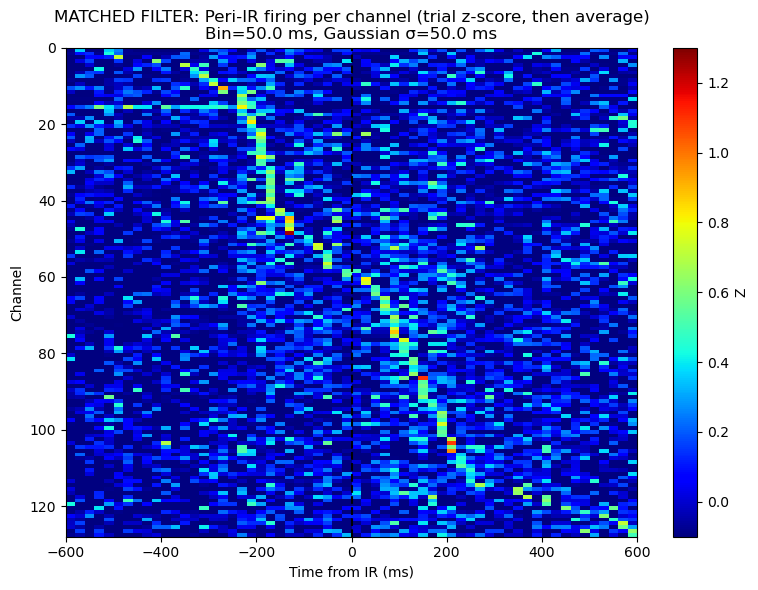

In [9]:
%matplotlib inline

def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

psth_plot, centers_from_edges = pad_bins_to_edges(psth_ch_sorted, centers_ms_control, edges_ms_control, tol=1e-3)

# plot
n_ch = psth_plot.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(8,6))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms_control,
    y_edges,
    psth_plot,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.invert_yaxis()
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"MATCHED FILTER: Peri-IR firing per channel (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.show()

## EKF + SGD learning of Poisson LDS using real data

In [10]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
from jax import vmap, value_and_grad, jit
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import (
    ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals,
    conditional_moments_gaussian_smoother as cmgs,
)
from dynamax.utils.utils import random_rotation

In [11]:
key = jr.key(0)
key1, key2 = jr.split(key, 2)

all_observations_control = jnp.array(counts_ch_control.transpose(0, 2, 1)) # (num_trials, num_timesteps, num_ch)
state_dim = 4
observations_dim, num_timesteps, num_trials = counts_ch_control.shape[1], counts_ch_control.shape[2], counts_ch_control.shape[0]

In [12]:
# Poisson LDS
 
# Initialization
d_init = jnp.mean(all_observations_control, axis=(0, 1))  # Average over trials and time steps for mean_rate_per_channel
C_init = 0.5 * jr.normal(key2, shape=(observations_dim, state_dim)) # Initialize C to be random values
log_d_init = jnp.log(d_init)
A_init = jnp.eye(state_dim)
theta = (C_init, log_d_init, A_init)

def make_params(C, d, A):
    return ParamsGGSSM(
        initial_mean=jnp.zeros(state_dim),
        initial_covariance=jnp.eye(state_dim),
        dynamics_function=lambda z: A @ z,
        dynamics_covariance=0.001 * jnp.eye(state_dim), # TODO tune this after looking at reconstruction error
        emission_mean_function=lambda z: softplus(C @ z + d),
        emission_cov_function=lambda z: jnp.diag(softplus(C @ z + d)),
        emission_dist=lambda mu, Sigma: Poisson(rate=softplus(mu)),
    )

def loss_fn(theta, observations):
    """
    Compute the negative log-likelihood using EKF like integrals. This is the Conditional Marginal Gaussian Smoother (CMGS) objective, which is an approximation to the true marginal log-likelihood.

    Returns:
        Negative log-likelihood + penalty for stability
    """
    C, log_d, A = theta
    sigma_max = jnp.linalg.norm(A, ord=2)
    penalty = 1e2 * jnp.maximum(0.0, sigma_max - 1.0) ** 2 # Constraining the spectral norm of A to be less than 1 for stability
    params = make_params(C, jnp.exp(log_d), A)
    posts = vmap(lambda e: cmgs(params, EKFIntegrals(), e))(observations) # Estimate CMGS marginal
    return -jnp.sum(posts.marginal_loglik) + penalty # Return regularized loss

# SGD
optimizer = optax.adam(5e-3)
opt_state = optimizer.init(theta)

@jit
def step(theta, opt_state, observations):
    """
    Perform descent step using the CMGS negative log-likelihood as the loss function.
    Use Adam + autograd to compute gradients.
    Note: This is equivalent to fit_sgd for LinearGaussianSSM, but fit_sgd is not defined for GeneralizedGaussianSSM

    Returns:
        Updated parameters
        New optimizer state
        Current loss
    """
    loss, grads = value_and_grad(loss_fn)(theta, observations)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(theta, updates), new_opt_state, loss

losses = []
n_epochs = 500
for epoch in range(n_epochs):
    theta, opt_state, loss = step(theta, opt_state, all_observations_control)
    losses.append(float(loss))
    if epoch % 25 == 0:
        print(f"epoch {epoch:4d}  neg-loglik = {loss:.2f}")

C_fit_control, log_d_fit_control, A_fit_control = theta
print('singular values of A_fit:', jnp.linalg.svd(A_fit_control, compute_uv=False))

epoch    0  neg-loglik = 218188.14
epoch   25  neg-loglik = 199819.75
epoch   50  neg-loglik = 172174.23
epoch   75  neg-loglik = 153609.66
epoch  100  neg-loglik = 148444.09
epoch  125  neg-loglik = 147174.39
epoch  150  neg-loglik = 146698.55
epoch  175  neg-loglik = 146469.78
epoch  200  neg-loglik = 146343.58
epoch  225  neg-loglik = 146267.89
epoch  250  neg-loglik = 146224.39
epoch  275  neg-loglik = 146199.48
epoch  300  neg-loglik = 146181.62
epoch  325  neg-loglik = 146165.66
epoch  350  neg-loglik = 146149.28
epoch  375  neg-loglik = 146127.70
epoch  400  neg-loglik = 146080.66
epoch  425  neg-loglik = 146065.30
epoch  450  neg-loglik = 146056.53
epoch  475  neg-loglik = 146049.41
singular values of A_fit: [1.3074495 1.0324062 0.9723871 0.7970213]


In [13]:
# Get latent trajectories
params_init = make_params(C_init, jnp.exp(log_d_init), A_init)
params_fit_control  = make_params(C_fit_control, jnp.exp(log_d_fit_control), A_fit_control)

# One extra step with CMGS to get true params gives us final latents
posts_init = vmap(lambda e: cmgs(params_init,  EKFIntegrals(), e))(all_observations_control)
posts_fit_control  = vmap(lambda e: cmgs(params_fit_control,   EKFIntegrals(), e))(all_observations_control)

predicted_all = softplus(posts_fit_control.filtered_means @ C_fit_control.T + jnp.exp(log_d_fit_control))
innovations_all = all_observations_control - predicted_all

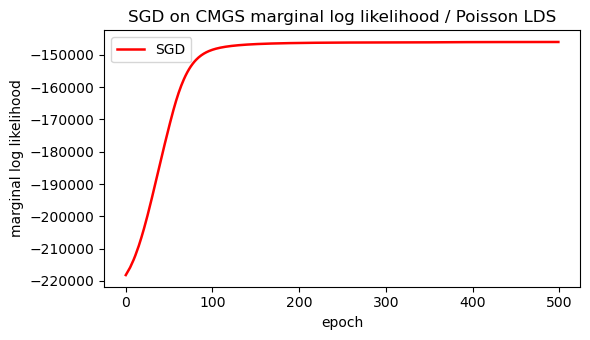

In [14]:
%matplotlib inline 
# Plot loss curve
plt.figure(figsize=(6, 3.5))
plt.plot(-jnp.array(losses), color="r", lw=1.8, label="SGD")
plt.xlabel("epoch"); plt.ylabel("marginal log likelihood")
plt.title("SGD on CMGS marginal log likelihood / Poisson LDS")
plt.legend(); plt.tight_layout()

In [15]:
t = jnp.arange(all_observations_control.shape[1])
i = 0
n_latents = posts_fit_control.filtered_covariances.shape[-1]
colors = {"init": "b", "fit": "r"}
labels = {"init": "init params", "fit": "fitted params"}

U, S, Vt = jnp.linalg.svd(C_fit_control, full_matrices=False)
R = Vt.T #@ jnp.diag(S)            # (latent_dim, latent_dim)

z_init = posts_init.filtered_means @ R
z_control  = posts_fit_control.filtered_means  @ R

# top_dims is trivially 0,1,2,... since SVD sorts descending
top_dims_rot = jnp.arange(n_latents)

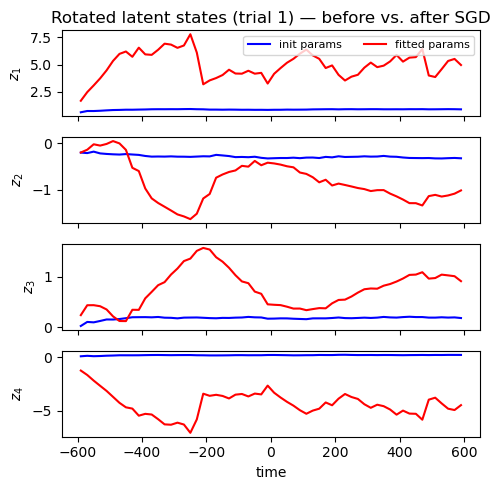

In [16]:
%matplotlib inline
disp_states = 4
disp_states = min(disp_states, z_control.shape[-1])
bin_centers_ms = 0.5 * (edges_ms_control[:-1] + edges_ms_control[1:])  # (T,), relative to IR

fig, axs = plt.subplots(disp_states, 1, figsize=(5, 5), sharex=True)
for d in range(disp_states):
    for tag, means_rot in [("init", z_init), ("fit", z_control)]:
        mu = means_rot[i, :, d]
        axs[d].plot(bin_centers_ms, mu, color=colors[tag], lw=1.5, label=labels[tag])
    axs[d].set_ylabel(rf"$z_{{{d+1}}}$")
axs[0].set_title(f"Rotated latent states (trial {i+1}) — before vs. after SGD")
axs[0].legend(fontsize=8, ncol=2)
axs[-1].set_xlabel("time")
plt.tight_layout()

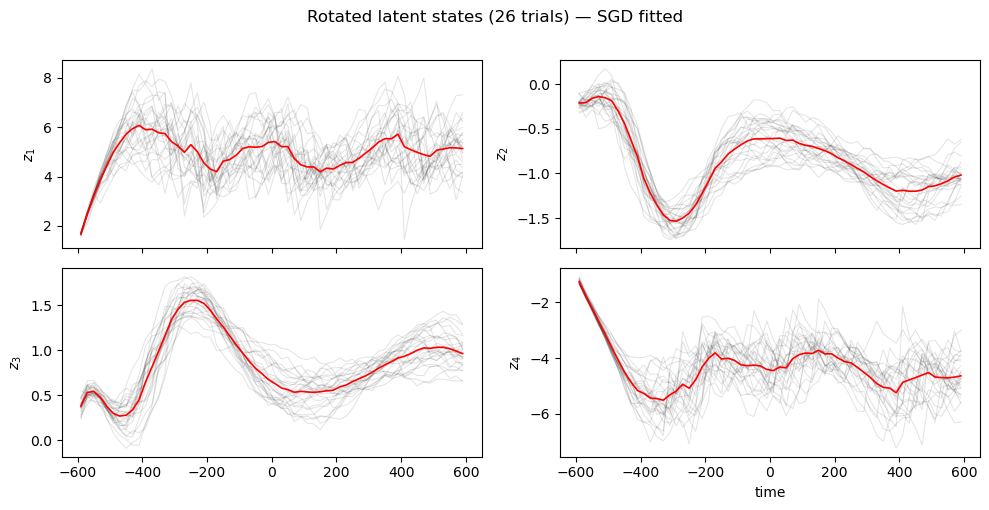

In [22]:
%matplotlib inline

n_rows = 2
n_cols = 2

n_trials = all_observations_control.shape[0]
mean_latents_rot = z_control.mean(axis=0)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharex=True)
axs_flat = axs.flatten()

for d in range(disp_states):
    ax = axs_flat[d]
    for i in range(n_trials):
        ax.plot(bin_centers_ms, z_control[i, :, d], color="k", lw=0.8, alpha=0.1)
    ax.plot(bin_centers_ms, mean_latents_rot[:, d], color="r", lw=1.2, alpha=1)
    ax.set_ylabel(rf"$z_{{{d+1}}}$")

for ax in axs_flat[disp_states:]:
    ax.set_visible(False)

axs_flat[disp_states - 1].set_xlabel("time")
fig.suptitle(f"Rotated latent states ({n_trials} trials) — SGD fitted", y=1.01)
plt.tight_layout()

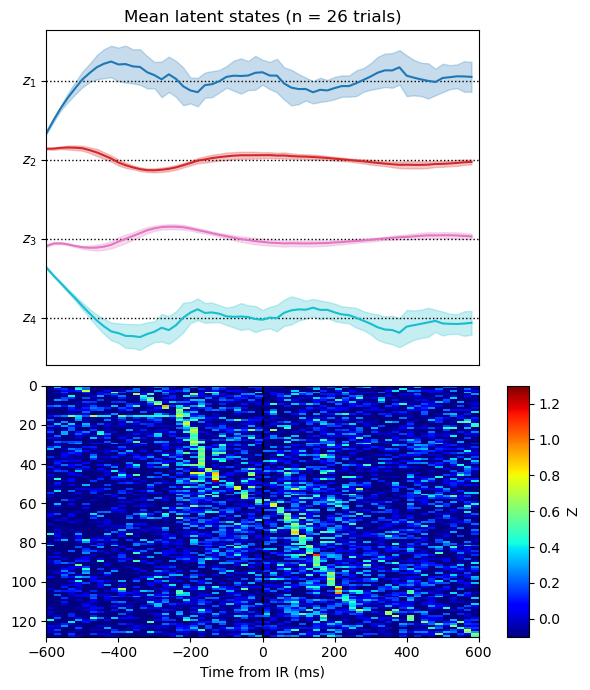

In [23]:
def plot_mean_latents_and_psth(means_rot, psth_plot, edges_ms,
                                disp_states=5, vmin=None, vmax=None):
    n_ch = psth_plot.shape[0]
    y_edges = np.arange(n_ch + 1)

    mean_latents = means_rot.mean(axis=0)  # (T, latent_dim)
    std_latents  = means_rot.std(axis=0)

    T = mean_latents.shape[0]
    t = jnp.arange(T)
    
    states = mean_latents[:, :disp_states]
    lim = 1.5 * abs(states - states.mean(axis=0)).max()

    colors = plt.cm.tab10(np.linspace(0, 1, disp_states))

    fig, axs = plt.subplots(2, 2,
                            height_ratios=[disp_states, 3],
                            width_ratios=(20, 1),
                            figsize=(6, 1 * disp_states + 3))

    ax = axs[0, 0]
    for d in range(disp_states):
        offset = -lim * d
        c = colors[d]
        ax.axhline(offset, color='k', ls=':', lw=1)
        mean_d = mean_latents[:, d]
        std_d  = std_latents[:, d]
        mu_c   = mean_d - mean_d.mean()
        ax.fill_between(t, mu_c - std_d + offset, mu_c + std_d + offset,
                        color=c, alpha=0.25)
        ax.plot(t, mu_c + offset, color=c, lw=1.5)

    ax.set_yticks(-jnp.arange(disp_states) * lim)
    ax.set_yticklabels([rf"$z_{{{d+1}}}$" for d in range(disp_states)])
    ax.set_xticks([])
    ax.set_xlim(0, T)
    ax.set_title(f"Mean latent states (n = {means_rot.shape[0]} trials)")
    axs[0, 1].set_visible(False)

    ax_bottom = axs[1, 0]
    ax_bottom.set_facecolor("0.5")
    pc = ax_bottom.pcolormesh(
        edges_ms, y_edges, psth_plot,
        shading="flat", cmap="jet", vmin=vmin, vmax=vmax,
    )
    ax_bottom.invert_yaxis()
    ax_bottom.axvline(0, linestyle="--", color="black")
    ax_bottom.set_ylim(n_ch, 0)
    ax_bottom.set_xlabel("Time from IR (ms)")
    plt.colorbar(pc, cax=axs[1, 1], label="Z")
    plt.tight_layout()

plot_mean_latents_and_psth(z_control, psth_plot, edges_ms_control,
                           disp_states=disp_states, vmin=-0.1, vmax=1.3)

In [24]:
import plotly.graph_objects as go
import numpy as np

def plot_latent_phase_portrait(means_rot, t_ms, alpha_trials=0.3):
    num_trials, num_timesteps, _ = means_rot.shape
    mean_across_trials = means_rot.mean(axis=0)

    ir_idx = int(jnp.argmin(jnp.abs(t_ms)))
    x, y, z = mean_across_trials[:, 0], mean_across_trials[:, 1], mean_across_trials[:, 2]

    fig = go.Figure()

    # individual trials
    for trial in range(num_trials):
        fig.add_trace(go.Scatter3d(
            x=means_rot[trial, :, 0],
            y=means_rot[trial, :, 1],
            z=means_rot[trial, :, 2],
            mode="lines",
            line=dict(color="gray", width=1),
            opacity=alpha_trials,
            showlegend=False,
        ))

    # mean trajectory colored by time
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode="markers+lines",
        marker=dict(size=3, color=t_ms, colorscale="Viridis", showscale=True,
            colorbar=dict(title="Time from IR (ms)", thickness=15, x=1.0)),
        line=dict(color="red", width=2),
        name="mean trajectory",
    ))

    # start / IR / end markers
    for px, py, pz, label, color in [
        (x[0],       y[0],       z[0],       "start",   "green"),
        (x[ir_idx],  y[ir_idx],  z[ir_idx],  "IR (t=0)","yellow"),
        (x[-1],      y[-1],      z[-1],       "end",     "red"),
    ]:
        fig.add_trace(go.Scatter3d(
            x=[px], y=[py], z=[pz],
            mode="markers",
            marker=dict(size=6, color=color),
            name=label,
        ))

    fig.update_layout(
        title=f"Latents 3D plot (top 3 / 4 SVD dims, n={num_trials} trials)",
        scene=dict(xaxis_title="z₁", yaxis_title="z₂", zaxis_title="z₃", aspectmode="cube"),  # equal box, each axis same physical length
        legend=dict(itemsizing="constant", x=1.15, y=0.4),
        margin=dict(l=0, r=0, b=0, t=40),
        width=1000,
        height=500,
    )
    colorbar=dict(title="Time from IR (ms)", thickness=15, x=1.0)
    return fig

fig = plot_latent_phase_portrait(z_control, centers_ms_control)
fig.update_layout(scene_camera=dict(
    eye=dict(x=1.75, y=0.75, z=0.75),
    center=dict(x=0, y=0, z=-0.2))
)
fig.show()

In [ ]:
fig.write_image("NPRW_trajectory_20ms_4_states_optimal.png", scale=2)  # scale=2 doubles DPI]
fig.write_html("NPRW_trajectory_20ms_4_states_optimal.html", include_plotlyjs=True, full_html=True)

## Reconstruction error

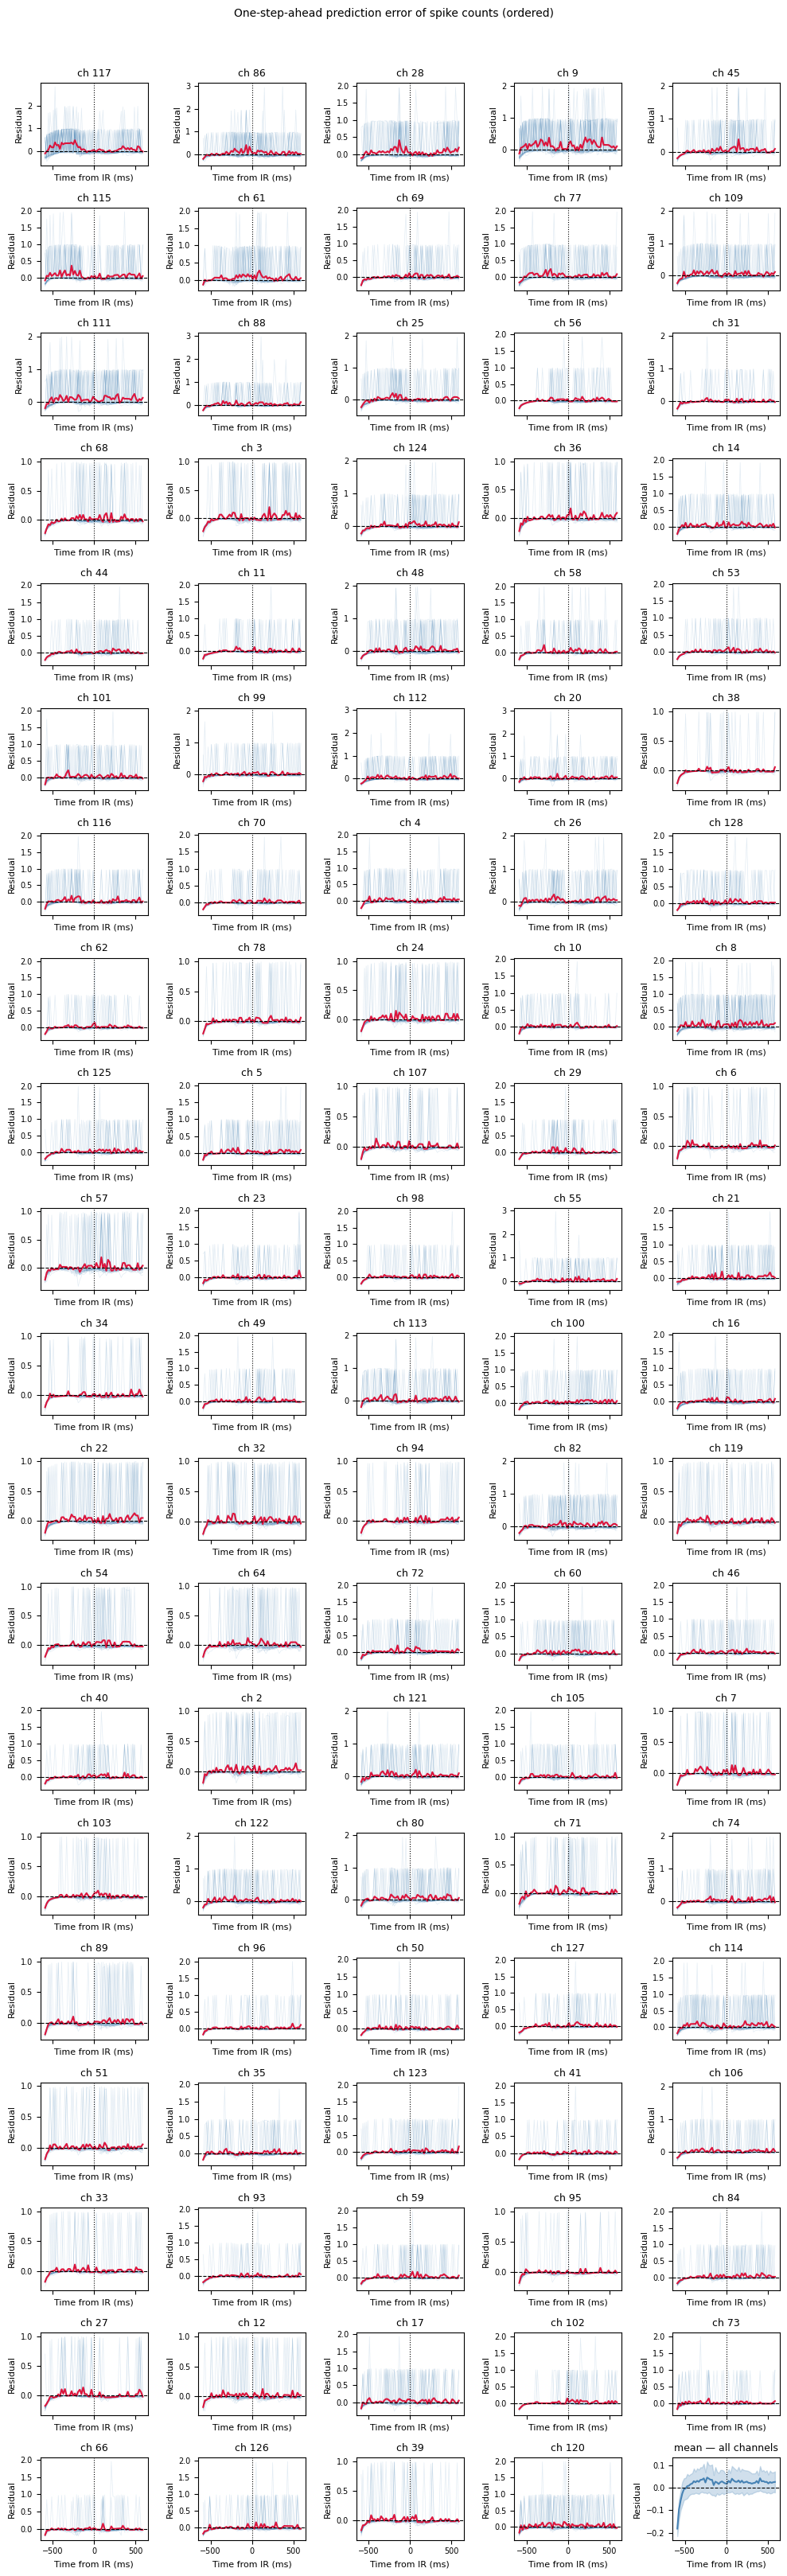

In [ ]:
# Plot residuals (innovations)
n_trials, T, obs_dim = innovations_all.shape

mean_innovation = np.array(innovations_all.mean(axis=0))   # (T, obs_dim)
innovations_np  = np.array(innovations_all)

# sort channels by max absolute mean innovation, descending
channel_order = np.argsort(np.abs(mean_innovation).max(axis=0))[::-1]

fig, axes = plt.subplots(20, 5, figsize=(10, 32), sharex=True, sharey=False)
axes_flat = axes.flatten()

for plot_idx, ch in enumerate(channel_order[:99]):
    ax = axes_flat[plot_idx]
    for i in range(n_trials):
        ax.plot(bin_centers_ms, innovations_np[i, :, ch],
                color='steelblue', alpha=0.15, linewidth=0.5)
    ax.plot(bin_centers_ms, mean_innovation[:, ch],
            color='crimson', linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
    # ax.set_ylim(-YLIM, YLIM)
    ax.set_title(f'ch {ch+1}', fontsize=9)

for ax in axes_flat:
    ax.set_xlabel('Time from IR (ms)', fontsize=8)
    ax.set_ylabel('Residual', fontsize=8)
    ax.tick_params(labelsize=7)

# mean across all channels — appended last
ax = axes_flat[-1]  # uncomment to re-enable mean panel
mean_across = mean_innovation.mean(axis=-1)
std_across  = mean_innovation.std(axis=-1)
ax.fill_between(bin_centers_ms,
                mean_across - std_across,
                mean_across + std_across,
                alpha=0.25, color='steelblue')
ax.plot(bin_centers_ms, mean_across, color='steelblue', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('mean — all channels', fontsize=9)

plt.suptitle('One-step-ahead prediction error of spike counts (ordered)', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## Cross Validate to determine number of latents

In [25]:
from sklearn.model_selection import KFold

def fit_and_eval(all_observations, state_dim, key, n_epochs=500, lr=5e-3):
    key1, key2 = jr.split(key)
    dynamics_matrix = random_rotation(key1, state_dim, theta=jnp.pi / 20)
    observations_dim = all_observations.shape[-1]
    mean_rate = jnp.mean(all_observations)

    def make_params(C, d):
        return ParamsGGSSM(
            initial_mean=jnp.zeros(state_dim),
            initial_covariance=jnp.eye(state_dim),
            dynamics_function=lambda z: dynamics_matrix @ z,
            dynamics_covariance=0.001 * jnp.eye(state_dim),
            emission_mean_function=lambda z: softplus(C @ z + d),
            emission_cov_function=lambda z: jnp.diag(softplus(C @ z + d)),
            emission_dist=lambda mu, Sigma: Poisson(rate=softplus(mu)),
        )

    def loss_fn(theta, obs):
        C, log_d = theta
        params = make_params(C, jnp.exp(log_d))
        posts = vmap(lambda e: cmgs(params, EKFIntegrals(), e))(obs)
        return -jnp.sum(posts.marginal_loglik)

    theta = (0.5 * jr.normal(key2, (observations_dim, state_dim)), jnp.log(mean_rate))
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(theta)

    @jit
    def step(theta, opt_state, obs):
        loss, grads = value_and_grad(loss_fn)(theta, obs)
        updates, new_opt_state = optimizer.update(grads, opt_state)
        return optax.apply_updates(theta, updates), new_opt_state, loss

    for _ in range(n_epochs):
        theta, opt_state, _ = step(theta, opt_state, all_observations)  # fit on train

    # eval on held-out
    C_fit, log_d_fit = theta
    params_fit = make_params(C_fit, jnp.exp(log_d_fit))
    return theta, params_fit

def eval_loglik(params_fit, obs):
    posts = vmap(lambda e: cmgs(params_fit, EKFIntegrals(), e))(obs)
    return jnp.sum(posts.marginal_loglik)

In [26]:
state_dims = [2, 3, 5, 8, 10, 15, 20]
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=0)
obs_np = np.array(all_observations_control)

results = {d: [] for d in state_dims}

for state_dim in state_dims:
    print(f"state_dim={state_dim}")
    for fold, (train_idx, val_idx) in enumerate(kf.split(obs_np)):
        key_fold = jr.key(fold * 100 + state_dim)
        train_obs = jnp.array(obs_np[train_idx])
        val_obs   = jnp.array(obs_np[val_idx])

        theta, params_fit = fit_and_eval(train_obs, state_dim, key_fold)
        ll = eval_loglik(params_fit, val_obs)
        results[state_dim].append(float(ll))
        print(f"  fold {fold}: val loglik = {ll:.2f}")

# summarize
mean_ll = {d: np.mean(v) for d, v in results.items()}
std_ll  = {d: np.std(v)  for d, v in results.items()}

state_dim=2


KeyboardInterrupt: 

In [27]:
%matplotlib inline

plt.figure(figsize=(6, 4))
dims = sorted(mean_ll)
plt.errorbar(dims, [mean_ll[d] for d in dims], yerr=[std_ll[d] for d in dims],
             marker='o', capsize=4)
plt.xlabel("# latent dimensions")
plt.ylabel("Marginal log likelihood")
plt.title("CV to pick # latents dimensions")
plt.tight_layout()

NameError: name 'mean_ll' is not defined

<Figure size 600x400 with 0 Axes>

## Map stim spikes to latents using control loading matrix

In [28]:
def plot_latent_phase_portrait_shared(
    z_control,
    z_stim,
    centers_ms_control,
    centers_ms_stim,
    alpha_trials=0.15,
    stim_z1_offset=0.0
):
    ir_c = int(np.argmin(np.abs(centers_ms_control)))
    ir_s = int(np.argmin(np.abs(centers_ms_stim)))

    def unpack(z):
        m = z.mean(axis=0)
        return m[:, 0], m[:, 1], m[:, 2]

    x_c, y_c, zc = unpack(z_control)
    x_s, y_s, zs = unpack(z_stim)
    
    ctrl_color = "red"
    stim_color = "blue"

    fig = go.Figure()

    # control trials
    for trial in range(z_control.shape[0]):
        fig.add_trace(go.Scatter3d(
            x=z_control[trial, :, 0],
            y=z_control[trial, :, 1],
            z=z_control[trial, :, 2],
            mode="lines",
            line=dict(color=ctrl_color, width=1),
            opacity=alpha_trials,
            showlegend=False,
        ))

    fig.add_trace(go.Scatter3d(
        x=x_c, y=y_c, z=zc,
        mode="markers+lines",
        marker=dict(size=3, color=centers_ms_control, colorscale="Viridis", showscale=False),
        line=dict(color="red", width=3),
        name="control mean",
    ))

    # stim trials
    for trial in range(z_stim.shape[0]):
        fig.add_trace(go.Scatter3d(
            x=z_stim[trial, :, 0] + stim_z1_offset,
            y=z_stim[trial, :, 1],
            z=z_stim[trial, :, 2],
            mode="lines",
            line=dict(color=stim_color, width=1),
            opacity=alpha_trials,
            showlegend=False,
        ))

    fig.add_trace(go.Scatter3d(
        x=x_s + stim_z1_offset, y=y_s, z=zs,
        mode="markers+lines",
        marker=dict(size=3, color=centers_ms_stim, colorscale="Viridis", showscale=True,
                    colorbar=dict(title="Time (ms)", thickness=15, x=1.0)),
        line=dict(color="blue", width=3),
        name="stim mean",
    ))

    # reference markers
    fig.add_trace(go.Scatter3d(
        x=[x_c[0]], y=[y_c[0]], z=[zc[0]],
        mode="markers",
        marker=dict(size=6, color="green"),
        name="control start"
    ))

    fig.add_trace(go.Scatter3d(
        x=[x_c[ir_c]], y=[y_c[ir_c]], z=[zc[ir_c]],
        mode="markers",
        marker=dict(size=6, color="yellow"),
        name="control IR"
    ))

    fig.add_trace(go.Scatter3d(
        x=[x_s[ir_s] + stim_z1_offset], y=[y_s[ir_s]], z=[zs[ir_s]],
        mode="markers",
        marker=dict(size=6, color="orange"),
        name="stim IR"
    ))

    fig.update_layout(
        title="Control vs Stim latent trajectories",
        scene=dict(
            xaxis_title="z₁",
            yaxis_title="z₂",
            zaxis_title="z₃",
            aspectmode="cube"
        ),
        legend=dict(itemsizing="constant", x=1.15, y=0.4),
        margin=dict(l=0, r=0, b=0, t=40),
        width=1000,
        height=500,
    )

    return fig

In [29]:
counts_ch_stim = stim_npz['NPRW_counts']
centers_ms_stim = stim_npz["NPRW_rel_t"]
edges_ms_stim = stim_npz["NPRW_edges_ms"]

In [30]:
# Freeze transition parameters and initial parameters, so that only covariance matrices are learned
key_1 = jr.key(1)
key1_1, key2_1 = jr.split(key, 2)

C_fit_control, log_d_fit_control, A_fit_control = theta
params_fit = make_params(C_fit_control, jnp.exp(log_d_fit_control), A_fit_control)

all_observations_stim = jnp.array(counts_ch_stim.transpose(0, 2, 1)) # (num_trials, num_timesteps, num_ch)
state_dim = 4
observations_dim, num_timesteps, num_trials = counts_ch_stim.shape[1], counts_ch_stim.shape[2], counts_ch_stim.shape[0]

## Fix params and project

In [31]:
params_fit_stim_1 = make_params(C_fit_control, jnp.exp(log_d_fit_control), A_fit_control)
posts_stim_1 = vmap(lambda e: cmgs(params_fit_stim_1, EKFIntegrals(), e))(all_observations_stim)
z_stim_1 = posts_stim_1.filtered_means @ R

In [32]:
# Plot without offset
fig = plot_latent_phase_portrait_shared(
    z_control=z_control,
    z_stim=z_stim_1,
    centers_ms_control=centers_ms_control,
    centers_ms_stim=centers_ms_stim,
    alpha_trials=0.05,
    stim_z1_offset=0.0
)

fig.update_layout(scene_camera=dict(
    eye=dict(x=1.75, y=0.75, z=0.75),
    center=dict(x=0, y=0, z=-0.2)
))

fig.show()

In [111]:
# fig.write_image("NPRW_trajectory_control_and_stim_overlap.png", scale=2)  # scale=2 doubles DPI]
fig.write_html("NPRW_trajectory_control_and_stim_overlap.html", include_plotlyjs=True, full_html=True)

In [33]:
# Plot with offset
fig = plot_latent_phase_portrait_shared(
    z_control=z_control,
    z_stim=z_stim_1,
    centers_ms_control=centers_ms_control,
    centers_ms_stim=centers_ms_stim,
    alpha_trials=0.1,
    stim_z1_offset=5.0
)

fig.update_layout(scene_camera=dict(
    eye=dict(x=1.75, y=0.75, z=0.75),
    center=dict(x=0, y=0, z=-0.2)
))

fig.show()

In [34]:
# fig.write_image("NPRW_trajectory_control_and_stim_offset.png", scale=2)  # scale=2 doubles DPI]
fig.write_html("NPRW_trajectory_control_and_stim_offset.html", include_plotlyjs=True, full_html=True)

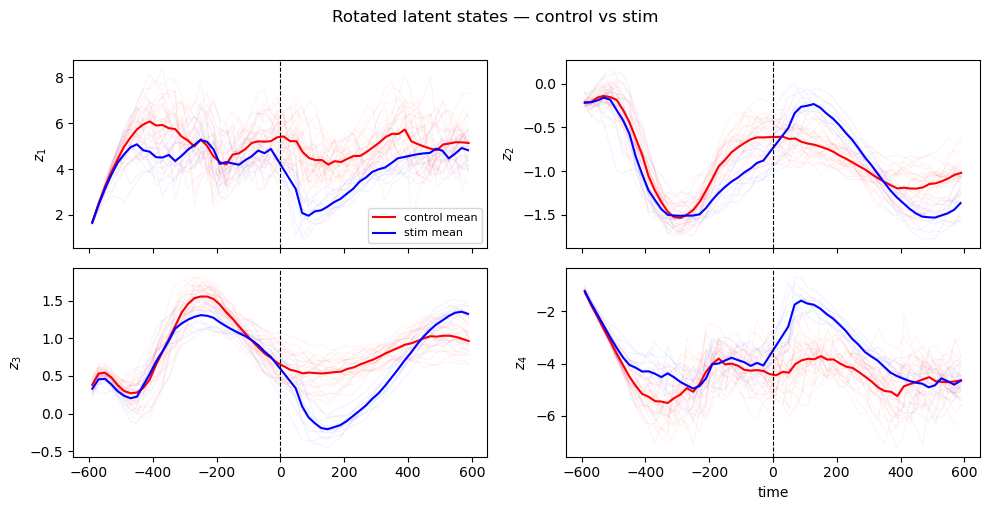

In [106]:
%matplotlib inline

n_rows = 2
n_cols = 2

n_trials_ctrl = z_control.shape[0]
n_trials_stim = z_stim_1.shape[0]

mean_ctrl = z_control.mean(axis=0)
mean_stim = z_stim_1.mean(axis=0)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharex=True)
axs_flat = axs.flatten()

ctrl_color = "red"
stim_color = "blue"

for d in range(disp_states):
    ax = axs_flat[d]

    # --- control trials ---
    for i in range(n_trials_ctrl):
        ax.plot(bin_centers_ms, z_control[i, :, d],
                color=ctrl_color, lw=0.8, alpha=0.05)

    ax.plot(bin_centers_ms, mean_ctrl[:, d],
            color="red", lw=1.5, label="control mean")

    # --- stim trials ---
    for i in range(n_trials_stim):
        ax.plot(centers_ms_stim, z_stim_1[i, :, d],
                color=stim_color, lw=0.8, alpha=0.05)

    ax.plot(centers_ms_stim, mean_stim[:, d],
            color="blue", lw=1.5, label="stim mean")
    
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')

    ax.set_ylabel(rf"$z_{{{d+1}}}$")

for ax in axs_flat[disp_states:]:
    ax.set_visible(False)

axs_flat[disp_states - 1].set_xlabel("time")
axs_flat[0].legend(fontsize=8)

fig.suptitle("Rotated latent states — control vs stim", y=1.01)
plt.tight_layout()

## Relax dynamics and refit

In [101]:
A = A_init

def loss_fn(A, observations):
    params = make_params(C_fit_control, jnp.exp(log_d_fit_control), A)
    posts = vmap(lambda e: cmgs(params, EKFIntegrals(), e))(observations)
    return -jnp.sum(posts.marginal_loglik)

# SGD
optimizer = optax.adam(5e-3)
opt_state = optimizer.init(A)

@jit
def step(A, opt_state, observations):
    loss, grads = value_and_grad(loss_fn)(A, observations)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    A = optax.apply_updates(A, updates)
    return A, new_opt_state, loss

for epoch in range(n_epochs):
    A, opt_state, loss = step(A, opt_state, all_observations_stim)

A_fit_stim = A
params_fit_stim_2 = make_params(C_fit_control, jnp.exp(log_d_fit_control), A_fit_stim)

In [102]:
posts_stim_2 = vmap(lambda e: cmgs(params_fit_stim_2, EKFIntegrals(), e))(all_observations_stim)

z_stim_2 = posts_stim_2.filtered_means @ R

fig = plot_latent_phase_portrait(z_stim_2, centers_ms_stim)
fig.update_layout(scene_camera=dict(
    eye=dict(x=1.75, y=0.75, z=0.75),
    center=dict(x=0, y=0, z=-0.2))
)
fig.show()

In [ ]:
fig = plot_latent_phase_portrait_shared(
    z_control=z_control,
    z_stim=z_stim_2,
    centers_ms_control=centers_ms_control,
    centers_ms_stim=centers_ms_stim,
    alpha_trials=0.05,
    stim_z1_offset=5.0
)

fig.update_layout(scene_camera=dict(
    eye=dict(x=1.75, y=0.75, z=0.75),
    center=dict(x=0, y=0, z=-0.2)
))

fig.show()

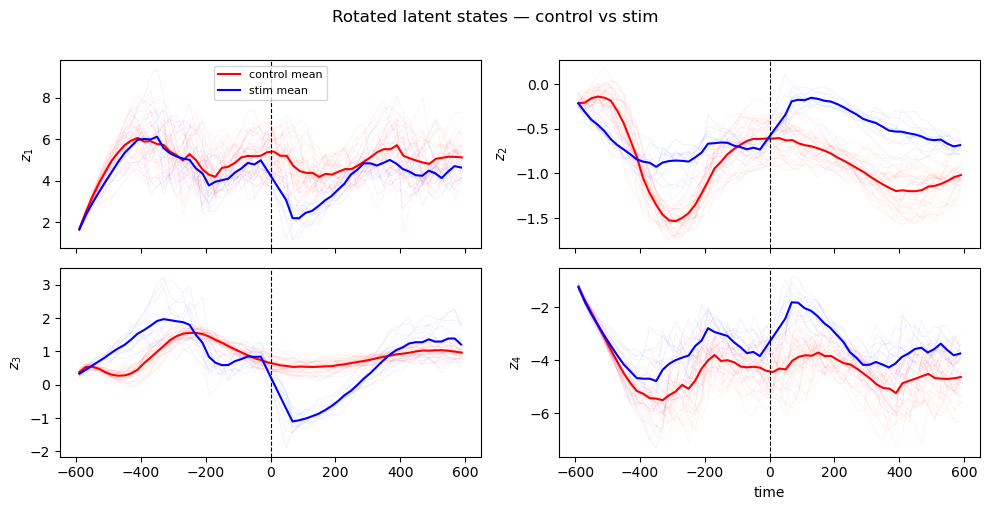

In [108]:
%matplotlib inline

n_rows = 2
n_cols = 2

n_trials_ctrl = z_control.shape[0]
n_trials_stim = z_stim_2.shape[0]

mean_ctrl = z_control.mean(axis=0)
mean_stim = z_stim_2.mean(axis=0)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharex=True)
axs_flat = axs.flatten()

ctrl_color = "red"
stim_color = "blue"

for d in range(disp_states):
    ax = axs_flat[d]

    # --- control trials ---
    for i in range(n_trials_ctrl):
        ax.plot(bin_centers_ms, z_control[i, :, d],
                color=ctrl_color, lw=0.8, alpha=0.05)

    ax.plot(bin_centers_ms, mean_ctrl[:, d],
            color="red", lw=1.5, label="control mean")

    # --- stim trials ---
    for i in range(n_trials_stim):
        ax.plot(centers_ms_stim, z_stim_2[i, :, d],
                color=stim_color, lw=0.8, alpha=0.05)

    ax.plot(centers_ms_stim, mean_stim[:, d],
            color="blue", lw=1.5, label="stim mean")
    
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')

    ax.set_ylabel(rf"$z_{{{d+1}}}$")

for ax in axs_flat[disp_states:]:
    ax.set_visible(False)

axs_flat[disp_states - 1].set_xlabel("time")
axs_flat[0].legend(fontsize=8)

fig.suptitle("Rotated latent states — control vs stim", y=1.01)
plt.tight_layout()